In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import scipy.stats as stats
from scipy import optimize
import random
import math
from collections import defaultdict

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

Step 1: Load and Explore Dataset

Informasi Dataset:
Jumlah data: 51708
Jumlah kolom: 9

Informasi kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51708 entries, 0 to 51707
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0       call_id     51708 non-null  int64 
 1   date            51708 non-null  object
 2   daily_caller    51708 non-null  int64 
 3   call_started    51708 non-null  object
 4   call_answered   51708 non-null  object
 5   call_ended      51708 non-null  object
 6   wait_length     51708 non-null  int64 
 7   service_length  51708 non-null  int64 
 8   meets_standard  51708 non-null  bool  
dtypes: bool(1), int64(4), object(4)
memory usage: 3.2+ MB
None

Sample data:
       call_id        date  daily_caller call_started call_answered  \
0            1  2021-01-01             1   8:00:00 AM    8:00:00 AM   
1            2  2021-01-01             2   8:02:42 AM    8:02:42 AM   
2          

C:\Users\Voire\AppData\Local\Temp\ipykernel_19016\2835038007.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
C:\Users\Voire\AppData\Local\Temp\ipykernel_19016\2835038007.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
C:\Users\Voire\AppData\Local\Temp\ipykernel_19016\2835038007.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])


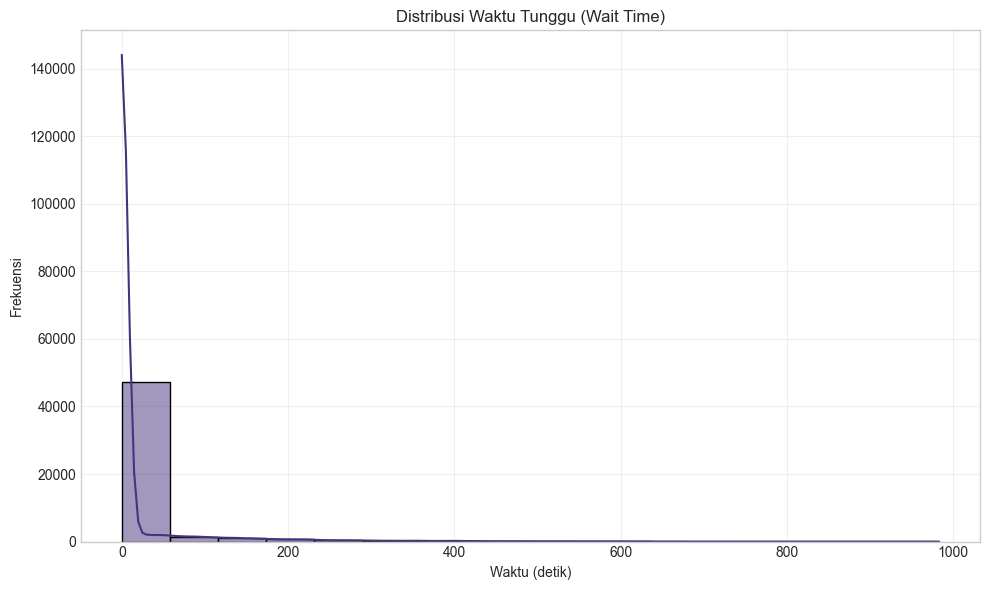

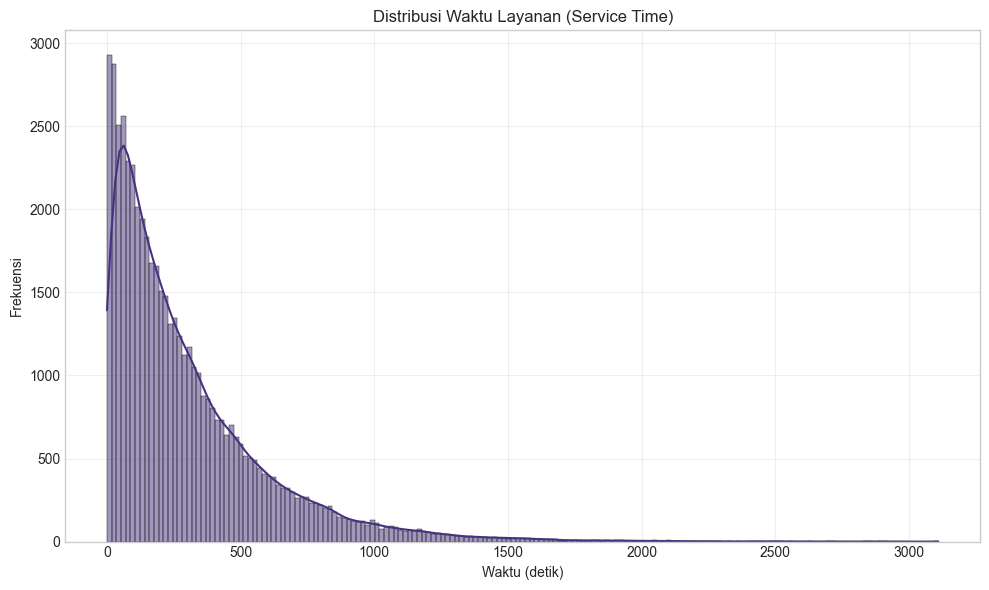

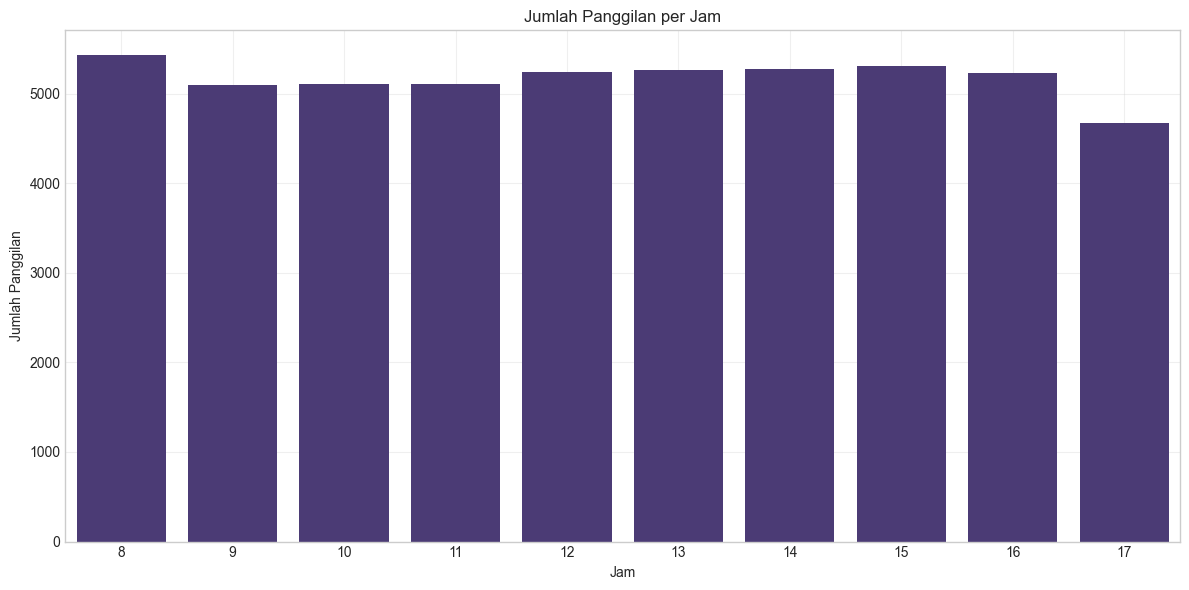

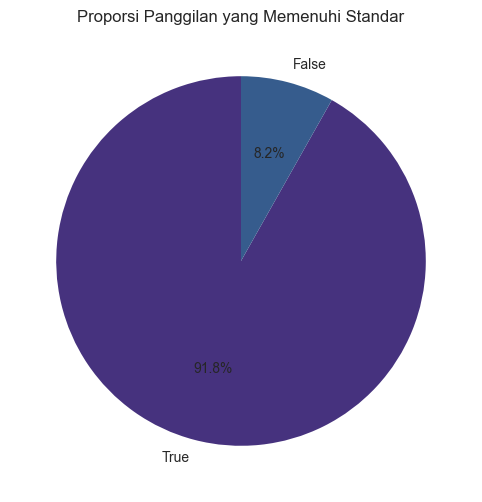

In [4]:
# ==========================================
# 1. Load and Explore Dataset
# ==========================================
print("Step 1: Load and Explore Dataset")

# Load dataset
df = pd.read_csv('simulated_call_centre.csv')

# Tampilkan informasi dasar dataset
print("\nInformasi Dataset:")
print(f"Jumlah data: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nInformasi kolom:")
print(df.info())

# Lihat beberapa data awal
print("\nSample data:")
print(df.head())

# Cek statistik deskriptif
print("\nStatistik deskriptif:")
print(df.describe())

# Cek nilai yang hilang
print("\nJumlah nilai yang hilang per kolom:")
print(df.isnull().sum())

# Persiapkan data
# Konversi kolom waktu menjadi datetime
time_columns = ['call_started', 'call_answered', 'call_ended']
for col in time_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Analisis waktu tunggu dan layanan
if 'wait_length' not in df.columns and 'call_started' in df.columns and 'call_answered' in df.columns:
    df['wait_length'] = (df['call_answered'] - df['call_started']).dt.total_seconds()

if 'service_length' not in df.columns and 'call_answered' in df.columns and 'call_ended' in df.columns:
    df['service_length'] = (df['call_ended'] - df['call_answered']).dt.total_seconds()

# Visualisasi distribusi waktu tunggu
plt.figure(figsize=(10, 6))
sns.histplot(df['wait_length'], kde=True)
plt.title('Distribusi Waktu Tunggu (Wait Time)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wait_time_distribution.png')
plt.show()

# Visualisasi distribusi waktu layanan
plt.figure(figsize=(10, 6))
sns.histplot(df['service_length'], kde=True)
plt.title('Distribusi Waktu Layanan (Service Time)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('service_time_distribution.png')
plt.show()

# Analisis pola kedatangan panggilan per jam
if 'call_started' in df.columns:
    df['hour'] = df['call_started'].dt.hour
    
    plt.figure(figsize=(12, 6))
    call_per_hour = df.groupby('hour').size()
    sns.barplot(x=call_per_hour.index, y=call_per_hour.values)
    plt.title('Jumlah Panggilan per Jam')
    plt.xlabel('Jam')
    plt.ylabel('Jumlah Panggilan')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('calls_per_hour.png')
    plt.show()

# Analisis proporsi panggilan yang memenuhi standar
if 'meets_standard' in df.columns:
    plt.figure(figsize=(8, 6))
    df['meets_standard'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title('Proporsi Panggilan yang Memenuhi Standar')
    plt.ylabel('')
    plt.savefig('standard_compliance.png')
    plt.show()


Step 2: Implement the Queueing Simulation

Distribusi terbaik untuk waktu antar kedatangan: expon
Parameter: (1.0, 0.3127508940953214)


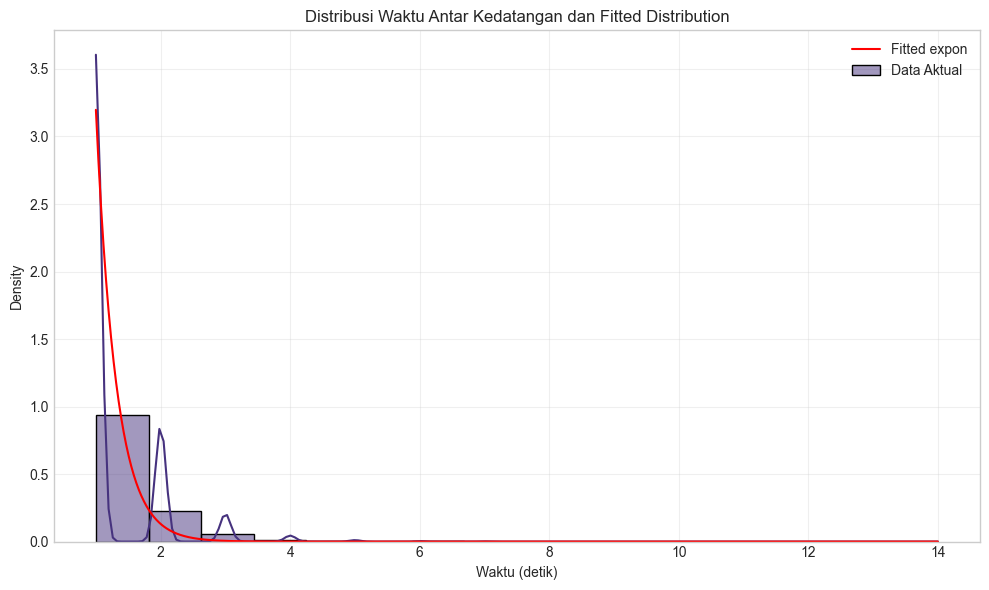

c:\Users\Voire\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_continuous_distns.py:6911: RuntimeWarning: divide by zero encountered in log
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)



Distribusi terbaik untuk waktu layanan: gamma
Parameter: (np.float64(0.9878156034507608), np.float64(-1.7638691693293404e-07), np.float64(300.9039731697095))


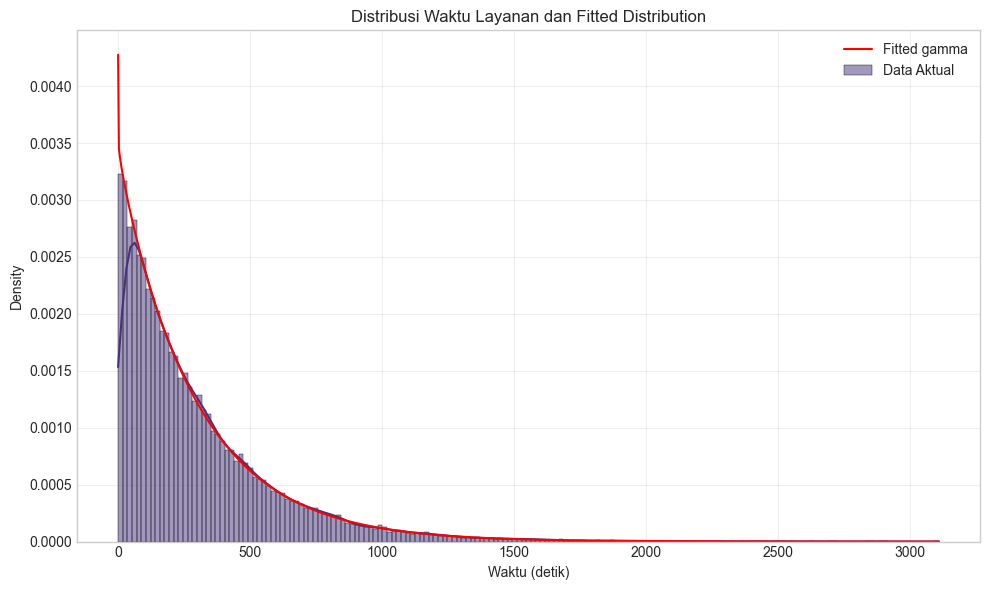


Jumlah agen berdasarkan pendekatan sederhana: 274


C:\Users\Voire\AppData\Local\Temp\ipykernel_19016\2038703583.py:263: RuntimeWarning: overflow encountered in scalar power
  sum_term = sum([(num_agents * rho)**n / math.factorial(n) for n in range(num_agents)])


In [5]:
# ==========================================
# 2. Implement the Queueing Simulation
# ==========================================
print("\nStep 2: Implement the Queueing Simulation")

def fit_distribution(data, dist_names=['expon', 'gamma', 'lognorm', 'weibull_min']):
    """Mencari distribusi terbaik yang cocok dengan data"""
    best_dist = None
    best_params = None
    best_sse = float('inf')
    
    for dist_name in dist_names:
        dist = getattr(stats, dist_name)
        try:
            # Fit distribusi ke data
            params = dist.fit(data)
            
            # Hitung SSE (Sum of Squared Errors)
            # Buat histogram dari data asli
            hist, bin_edges = np.histogram(data, bins=50, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Hitung PDF untuk distribusi yang di-fit
            pdf = dist.pdf(bin_centers, *params[:-2], loc=params[-2], scale=params[-1])
            
            # Hitung SSE
            sse = np.sum((hist - pdf) ** 2)
            
            if sse < best_sse:
                best_dist = dist_name
                best_params = params
                best_sse = sse
        except:
            continue
    
    return best_dist, best_params, best_sse

# Fit distribusi untuk waktu kedatangan
if 'call_started' in df.columns:
    # Urutkan berdasarkan waktu mulai panggilan
    df_sorted = df.sort_values('call_started')
    
    # Hitung waktu antar kedatangan (dalam detik)
    inter_arrival_times = []
    for i in range(1, len(df_sorted)):
        time_diff = (df_sorted['call_started'].iloc[i] - df_sorted['call_started'].iloc[i-1]).total_seconds()
        if time_diff > 0:  # Menghindari waktu negatif
            inter_arrival_times.append(time_diff)
    
    # Fit distribusi untuk waktu antar kedatangan
    arrival_dist, arrival_params, _ = fit_distribution(inter_arrival_times)
    print(f"\nDistribusi terbaik untuk waktu antar kedatangan: {arrival_dist}")
    print(f"Parameter: {arrival_params}")
    
    # Visualisasi hasil fitting untuk waktu antar kedatangan
    plt.figure(figsize=(10, 6))
    sns.histplot(inter_arrival_times, kde=True, stat='density', label='Data Aktual')
    
    # Generate x values for plotting the fitted distribution
    x = np.linspace(min(inter_arrival_times), max(inter_arrival_times), 1000)
    dist = getattr(stats, arrival_dist)
    y = dist.pdf(x, *arrival_params[:-2], loc=arrival_params[-2], scale=arrival_params[-1])
    
    plt.plot(x, y, 'r-', label=f'Fitted {arrival_dist}')
    plt.title('Distribusi Waktu Antar Kedatangan dan Fitted Distribution')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('interarrival_distribution_fit.png')
    plt.show()

# Fit distribusi untuk waktu layanan
service_dist, service_params, _ = fit_distribution(df['service_length'].dropna())
print(f"\nDistribusi terbaik untuk waktu layanan: {service_dist}")
print(f"Parameter: {service_params}")

# Visualisasi hasil fitting untuk waktu layanan
plt.figure(figsize=(10, 6))
sns.histplot(df['service_length'].dropna(), kde=True, stat='density', label='Data Aktual')

# Generate x values for plotting the fitted distribution
x = np.linspace(min(df['service_length'].dropna()), max(df['service_length'].dropna()), 1000)
dist = getattr(stats, service_dist)
y = dist.pdf(x, *service_params[:-2], loc=service_params[-2], scale=service_params[-1])

plt.plot(x, y, 'r-', label=f'Fitted {service_dist}')
plt.title('Distribusi Waktu Layanan dan Fitted Distribution')
plt.xlabel('Waktu (detik)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('service_distribution_fit.png')
plt.show()

# Implementasi simulasi antrian
class CallCenterSimulation:
    def __init__(self, arrival_dist, arrival_params, service_dist, service_params, num_agents, simulation_duration, warm_up_time=0):
        self.arrival_dist = arrival_dist
        self.arrival_params = arrival_params
        self.service_dist = service_dist
        self.service_params = service_params
        self.num_agents = num_agents
        self.simulation_duration = simulation_duration  # dalam detik
        self.warm_up_time = warm_up_time  # waktu warm-up dalam detik
        
        # Inisialisasi atribut simulasi
        self.current_time = 0
        self.next_arrival_time = 0
        self.queue = []
        self.agents = [0] * num_agents  # 0 menandakan agent bebas
        self.completed_calls = []
        self.queued_calls = []
        self.all_calls = []
        
    def generate_interarrival_time(self):
        """Generate waktu antar kedatangan berdasarkan distribusi yang dipilih"""
        dist = getattr(stats, self.arrival_dist)
        return dist.rvs(*self.arrival_params[:-2], loc=self.arrival_params[-2], scale=self.arrival_params[-1])
    
    def generate_service_time(self):
        """Generate waktu layanan berdasarkan distribusi yang dipilih"""
        dist = getattr(stats, self.service_dist)
        return dist.rvs(*self.service_params[:-2], loc=self.service_params[-2], scale=self.service_params[-1])
    
    def run_simulation(self):
        """Jalankan simulasi"""
        # Reset semua atribut
        self.current_time = 0
        self.next_arrival_time = self.generate_interarrival_time()
        self.queue = []
        self.agents = [0] * self.num_agents
        self.completed_calls = []
        self.queued_calls = []
        self.all_calls = []
        
        # Loop utama simulasi
        while self.current_time < self.simulation_duration:
            # Temukan event berikutnya (kedatangan atau selesai layanan)
            next_completion_time = min([t for t in self.agents if t > 0], default=float('inf'))
            
            if self.next_arrival_time < next_completion_time:
                # Proses kedatangan
                self.current_time = self.next_arrival_time
                self.process_arrival()
                self.next_arrival_time = self.current_time + self.generate_interarrival_time()
            else:
                # Proses selesai layanan
                self.current_time = next_completion_time
                self.process_completion()
        
        # Filter out data dari masa warm-up
        if self.warm_up_time > 0:
            self.completed_calls = [call for call in self.completed_calls if call['arrival_time'] >= self.warm_up_time]
    
    def process_arrival(self):
        """Proses kedatangan panggilan baru"""
        # Cari agent yang tersedia
        available_agent = next((i for i, t in enumerate(self.agents) if t == 0), None)
        
        call = {
            'arrival_time': self.current_time,
            'start_service_time': None,
            'completion_time': None,
            'wait_time': None,
            'service_time': None
        }
        
        self.all_calls.append(call)
        
        if available_agent is not None:
            # Agent tersedia, langsung layani
            service_time = self.generate_service_time()
            self.agents[available_agent] = self.current_time + service_time
            
            call['start_service_time'] = self.current_time
            call['service_time'] = service_time
            call['completion_time'] = self.current_time + service_time
            call['wait_time'] = 0
        else:
            # Tidak ada agent tersedia, masuk antrian
            self.queue.append({
                'arrival_time': self.current_time,
                'call_index': len(self.all_calls) - 1
            })
            self.queued_calls.append(call)
    
    def process_completion(self):
        """Proses selesainya layanan panggilan"""
        # Temukan agent yang selesai
        agent_index = self.agents.index(self.current_time)
        self.agents[agent_index] = 0  # Set agent menjadi bebas
        
        # Jika ada di antrian, layani panggilan berikutnya
        if self.queue:
            queued_call = self.queue.pop(0)
            service_time = self.generate_service_time()
            self.agents[agent_index] = self.current_time + service_time
            
            call_index = queued_call['call_index']
            self.all_calls[call_index]['start_service_time'] = self.current_time
            self.all_calls[call_index]['service_time'] = service_time
            self.all_calls[call_index]['completion_time'] = self.current_time + service_time
            self.all_calls[call_index]['wait_time'] = self.current_time - queued_call['arrival_time']
    
    def get_completed_calls(self):
        """Dapatkan panggilan yang telah selesai"""
        return [call for call in self.all_calls if call['completion_time'] is not None]
    
    def get_performance_metrics(self):
        """Hitung metrik performa"""
        completed_calls = self.get_completed_calls()
        
        if not completed_calls:
            return {
                'avg_wait_time': 0,
                'avg_service_time': 0,
                'avg_total_time': 0,
                'max_wait_time': 0,
                'max_queue_length': 0,
                'service_level': 0,
                'abandonment_rate': 0
            }
        
        # Hitung metrik dasar
        wait_times = [call['wait_time'] for call in completed_calls]
        service_times = [call['service_time'] for call in completed_calls]
        total_times = [call['wait_time'] + call['service_time'] for call in completed_calls]
        
        # Hitung service level (persentase panggilan yang menunggu kurang dari threshold)
        threshold = 60  # Anggap 60 detik sebagai threshold
        calls_within_threshold = sum(1 for t in wait_times if t <= threshold)
        
        return {
            'avg_wait_time': np.mean(wait_times),
            'avg_service_time': np.mean(service_times),
            'avg_total_time': np.mean(total_times),
            'max_wait_time': max(wait_times) if wait_times else 0,
            'max_queue_length': max([len(self.queue) for _ in range(len(completed_calls))]),
            'service_level': calls_within_threshold / len(completed_calls) * 100 if completed_calls else 0,
            'utilization': np.mean([1 - (agent == 0) for agent in self.agents]) * 100
        }
        
# Hitung jumlah agen yang optimal berdasarkan data
# Akan digunakan model M/M/c
def calculate_optimal_agents(arrival_rate, service_rate, target_wait_time=60):
    """
    Menghitung jumlah agen yang optimal menggunakan model M/M/c
    arrival_rate: tingkat kedatangan (panggilan per detik)
    service_rate: tingkat layanan (panggilan per detik)
    target_wait_time: target waktu tunggu dalam detik
    """
    # Intensitas lalu lintas per agen
    rho = arrival_rate / service_rate
    
    # Mulai dari minimal 1 agen
    num_agents = math.ceil(rho) + 1
    
    while True:
        # Hitung probabilitas semua agen sibuk (P0)
        sum_term = sum([(num_agents * rho)**n / math.factorial(n) for n in range(num_agents)])
        final_term = (num_agents * rho)**num_agents / (math.factorial(num_agents) * (1 - rho/num_agents))
        P0 = 1 / (sum_term + final_term)
        
        # Hitung rata-rata panjang antrian (Lq)
        Lq = P0 * (rho**num_agents) * rho / (math.factorial(num_agents) * (1 - rho/num_agents)**2)
        
        # Hitung rata-rata waktu tunggu (Wq)
        Wq = Lq / arrival_rate
        
        # Jika waktu tunggu kurang dari target, return jumlah agen
        if Wq <= target_wait_time:
            return num_agents
        
        num_agents += 1

# Menghitung rata-rata waktu antar kedatangan dan waktu layanan
if 'inter_arrival_times' in locals():
    avg_interarrival_time = np.mean(inter_arrival_times)
    arrival_rate = 1 / avg_interarrival_time  # kedatangan per detik
else:
    # Gunakan estimasi jika tidak ada data waktu antar kedatangan
    arrival_rate = len(df) / ((df['call_started'].max() - df['call_started'].min()).total_seconds())

avg_service_time = df['service_length'].mean()
service_rate = 1 / avg_service_time  # layanan per detik

# Gunakan kedua distribusi yang telah di-fit untuk simulasi
# Tentukan jumlah agen awal berdasarkan perhitungan
try:
    optimal_agents = calculate_optimal_agents(arrival_rate, service_rate)
    print(f"\nJumlah agen optimal berdasarkan model M/M/c: {optimal_agents}")
except:
    # Jika gagal menghitung, gunakan pendekatan sederhana
    optimal_agents = math.ceil(arrival_rate / service_rate * 1.2)  # Tambah 20% margin
    print(f"\nJumlah agen berdasarkan pendekatan sederhana: {optimal_agents}")



Step 3: Performance Analysis and Visualization

Menjalankan simulasi dengan 269 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 79.55%

Menjalankan simulasi dengan 270 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 89.26%

Menjalankan simulasi dengan 271 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 81.18%

Menjalankan simulasi dengan 272 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 83.09%

Menjalankan simulasi dengan 273 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 76.92%

Menjalankan simulasi dengan 274 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 83.58%

Menjalankan simulasi dengan 275 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 85.45%

Menjalankan simulasi dengan 276 agen...
  Avg Wait Time: 0.00 detik
  Service Level: 100.00%
  Utilization: 84.06%

Menjalankan simulasi de

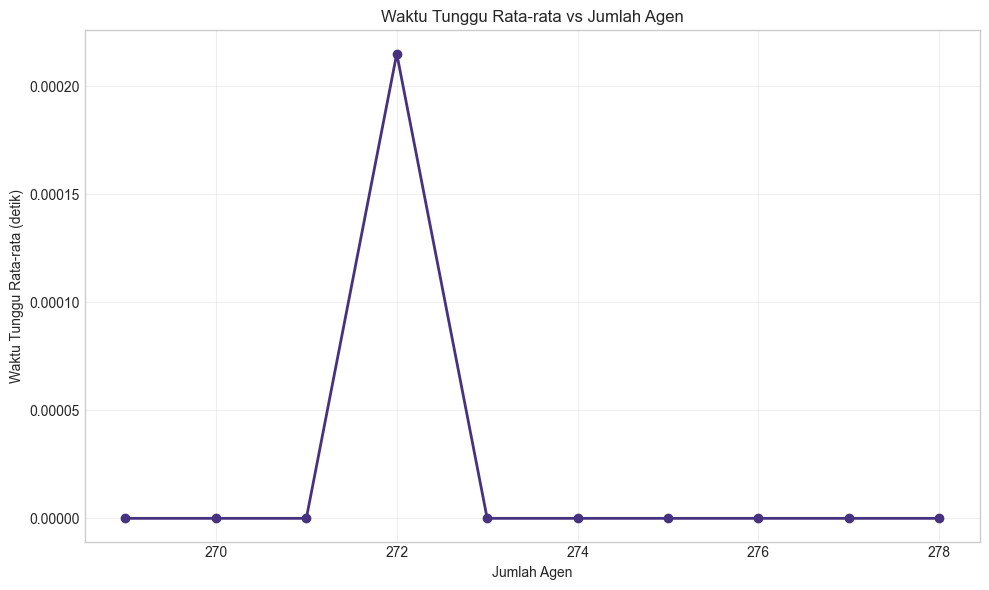

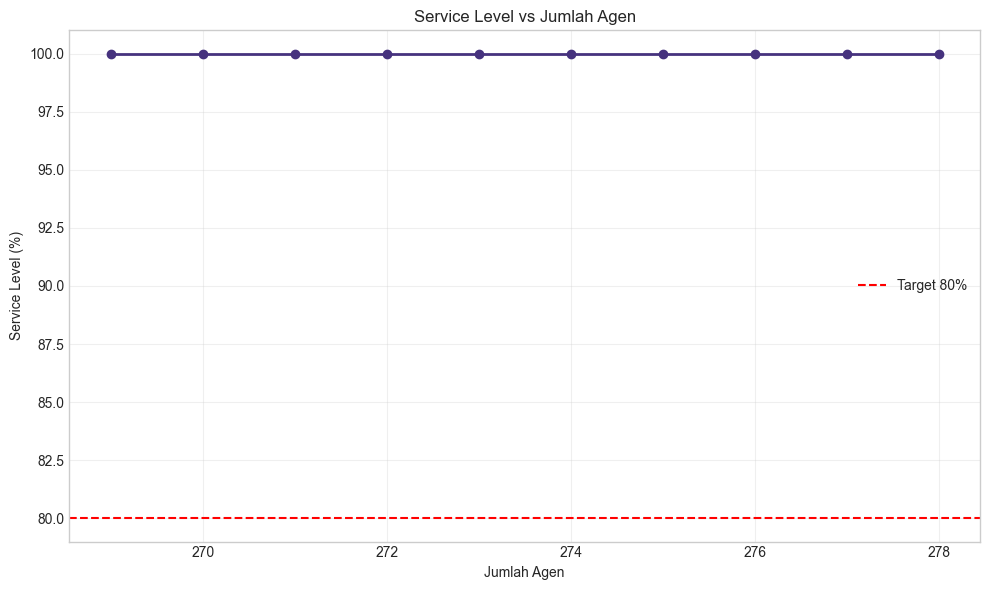

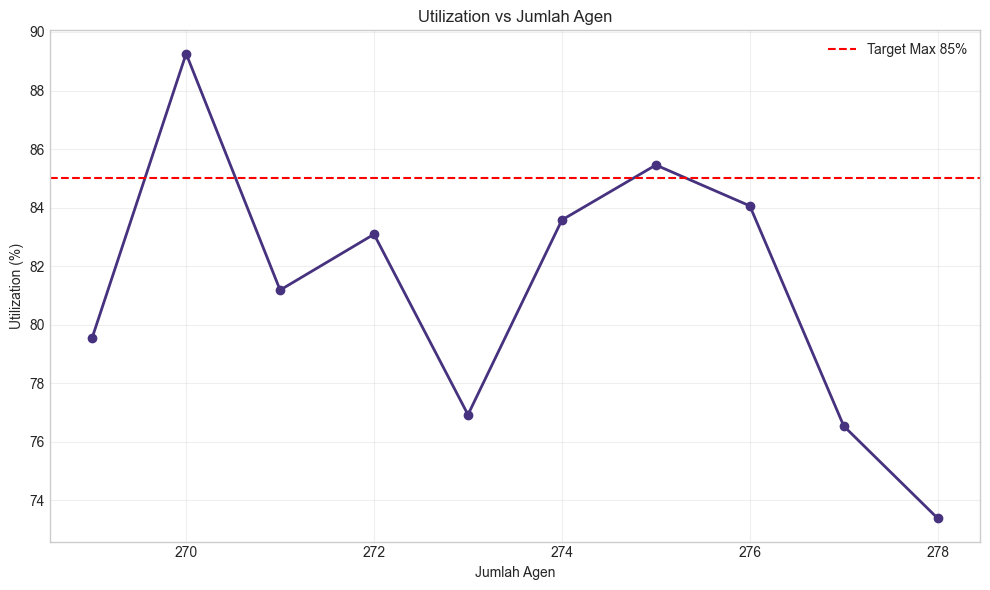

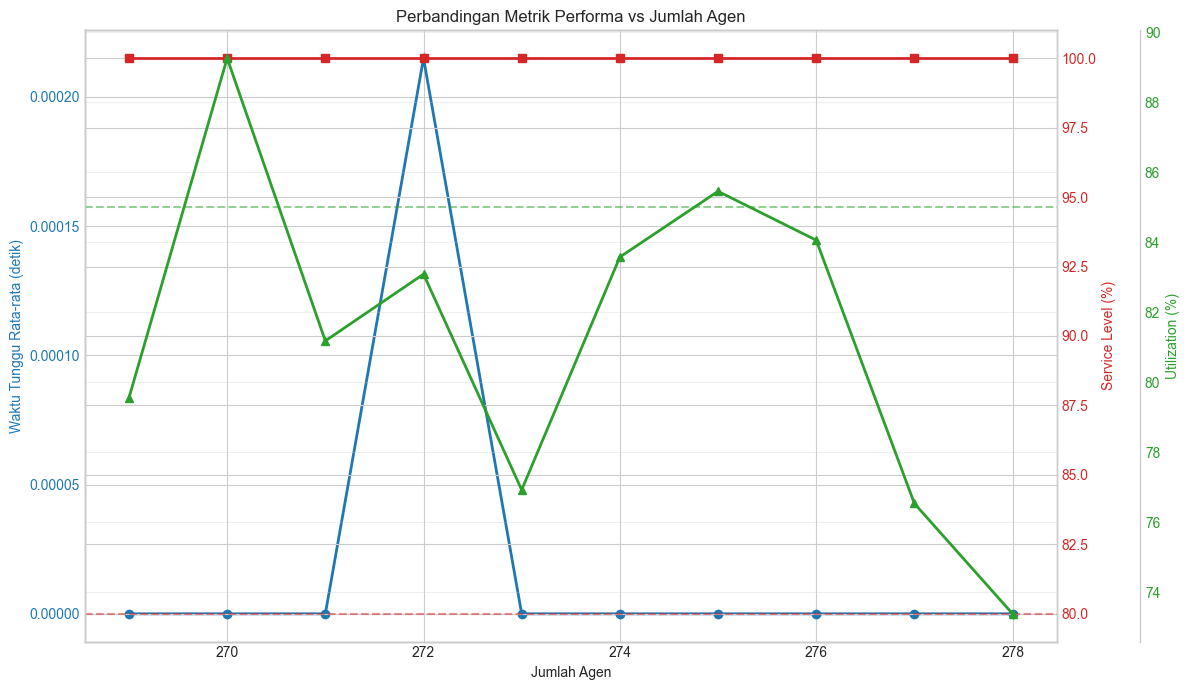

In [6]:
# ==========================================
# 3. Performance Analysis and Visualization
# ==========================================
print("\nStep 3: Performance Analysis and Visualization")

# Jalankan simulasi dengan jumlah agen yang berbeda
simulation_duration = 24 * 60 * 60  # 24 jam dalam detik
warm_up_time = 1 * 60 * 60  # 1 jam warm-up

results = []
agent_counts = range(max(1, optimal_agents - 5), optimal_agents + 5)

for num_agents in agent_counts:
    print(f"\nMenjalankan simulasi dengan {num_agents} agen...")
    sim = CallCenterSimulation(
        arrival_dist=arrival_dist, 
        arrival_params=arrival_params,
        service_dist=service_dist, 
        service_params=service_params,
        num_agents=num_agents,
        simulation_duration=simulation_duration,
        warm_up_time=warm_up_time
    )
    
    sim.run_simulation()
    metrics = sim.get_performance_metrics()
    metrics['num_agents'] = num_agents
    results.append(metrics)
    
    print(f"  Avg Wait Time: {metrics['avg_wait_time']:.2f} detik")
    print(f"  Service Level: {metrics['service_level']:.2f}%")
    print(f"  Utilization: {metrics['utilization']:.2f}%")

# Buat DataFrame dari hasil simulasi
results_df = pd.DataFrame(results)

# Visualisasi hasil
# 1. Plot waktu tunggu rata-rata vs jumlah agen
plt.figure(figsize=(10, 6))
plt.plot(results_df['num_agents'], results_df['avg_wait_time'], 'o-', linewidth=2)
plt.title('Waktu Tunggu Rata-rata vs Jumlah Agen')
plt.xlabel('Jumlah Agen')
plt.ylabel('Waktu Tunggu Rata-rata (detik)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_wait_time_vs_agents.png')
plt.show()

# 2. Plot Service Level vs jumlah agen
plt.figure(figsize=(10, 6))
plt.plot(results_df['num_agents'], results_df['service_level'], 'o-', linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='Target 80%')
plt.title('Service Level vs Jumlah Agen')
plt.xlabel('Jumlah Agen')
plt.ylabel('Service Level (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('service_level_vs_agents.png')
plt.show()

# 3. Plot Utilization vs jumlah agen
plt.figure(figsize=(10, 6))
plt.plot(results_df['num_agents'], results_df['utilization'], 'o-', linewidth=2)
plt.axhline(y=85, color='r', linestyle='--', label='Target Max 85%')
plt.title('Utilization vs Jumlah Agen')
plt.xlabel('Jumlah Agen')
plt.ylabel('Utilization (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('utilization_vs_agents.png')
plt.show()

# 4. Grafik perbandingan antara waktu tunggu, service level, dan utilization
fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Agen')
ax1.set_ylabel('Waktu Tunggu Rata-rata (detik)', color=color)
ax1.plot(results_df['num_agents'], results_df['avg_wait_time'], 'o-', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Service Level (%)', color=color)
ax2.plot(results_df['num_agents'], results_df['service_level'], 's-', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=80, color=color, linestyle='--', alpha=0.5)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:green'
ax3.set_ylabel('Utilization (%)', color=color)
ax3.plot(results_df['num_agents'], results_df['utilization'], '^-', color=color, linewidth=2)
ax3.tick_params(axis='y', labelcolor=color)
ax3.axhline(y=85, color=color, linestyle='--', alpha=0.5)

plt.title('Perbandingan Metrik Performa vs Jumlah Agen')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_comparison.png')
plt.show()


Step 4: Modify Parameters and Optimize

Jumlah agen optimal untuk service level 80%: 269.0


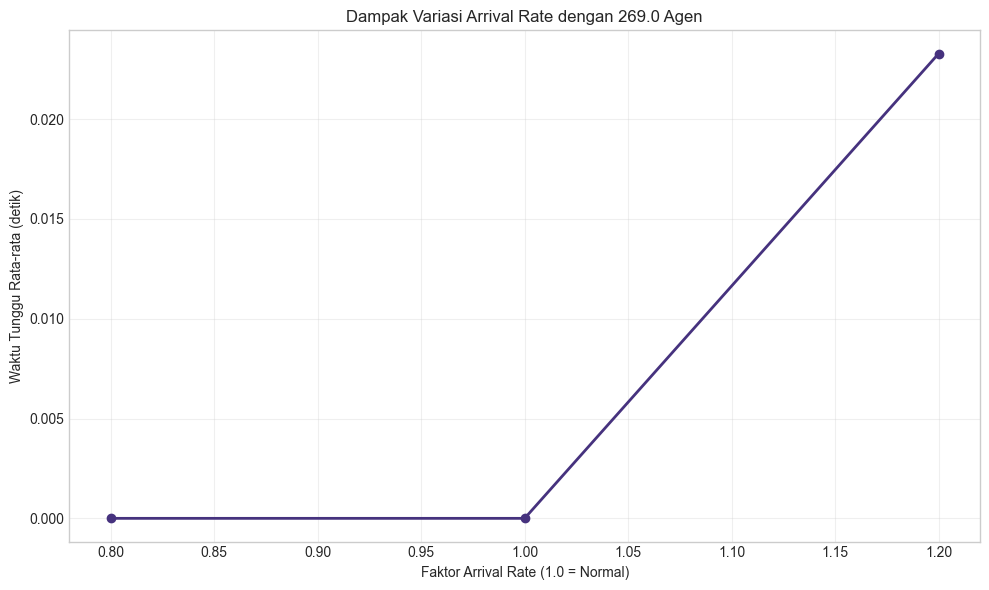

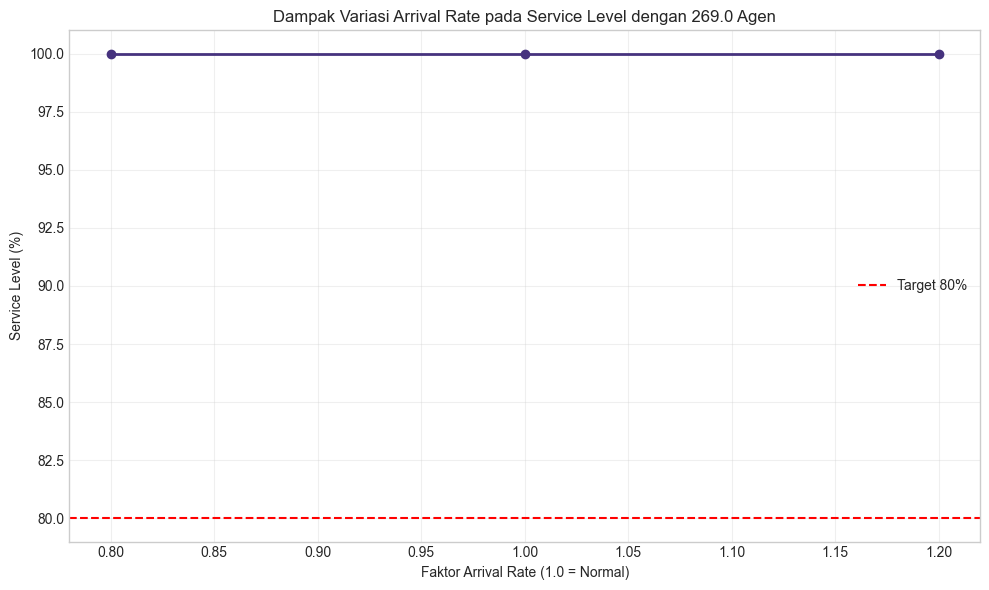

C:\Users\Voire\AppData\Local\Temp\ipykernel_19016\2038703583.py:263: RuntimeWarning: overflow encountered in scalar power
  sum_term = sum([(num_agents * rho)**n / math.factorial(n) for n in range(num_agents)])


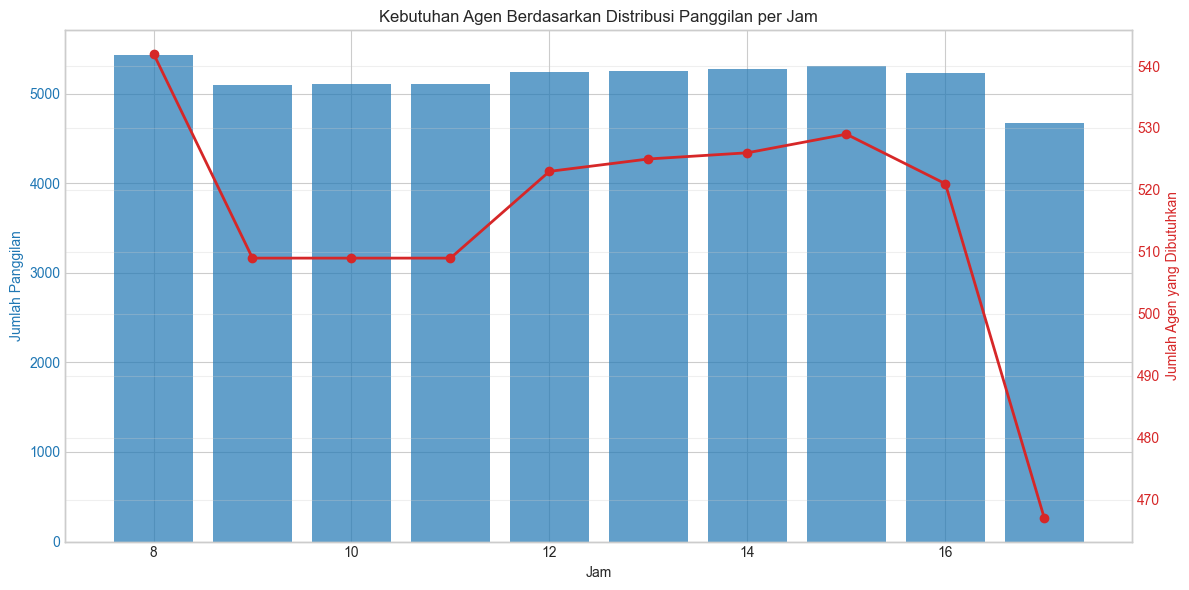

In [8]:
# ==========================================
# 4. Modify Parameters and Optimize
# ==========================================
print("\nStep 4: Modify Parameters and Optimize")

# Temukan jumlah agen optimal berdasarkan target service level
target_service_level = 80  # 80% panggilan dijawab dalam threshold
optimal_agent_count = None

for _, row in results_df.iterrows():
    if row['service_level'] >= target_service_level:
        optimal_agent_count = row['num_agents']
        break

print(f"\nJumlah agen optimal untuk service level {target_service_level}%: {optimal_agent_count}")

# Evaluasi dampak perubahan parameter lain
# 1. Variasi arrival rate (simulasikan peningkatan/penurunan volume panggilan)
arrival_variations = [0.8, 1.0, 1.2]  # 80%, 100%, 120% dari arrival rate saat ini
variation_results = []

for variation in arrival_variations:
    # Modifikasi parameter distribusi untuk arrival rate yang baru
    modified_arrival_params = list(arrival_params)
    modified_arrival_params[-1] = arrival_params[-1] / variation  # Ubah scale untuk mengubah arrival rate
    
    sim = CallCenterSimulation(
        arrival_dist=arrival_dist, 
        arrival_params=tuple(modified_arrival_params),
        service_dist=service_dist, 
        service_params=service_params,
        num_agents=int(optimal_agent_count),
        simulation_duration=simulation_duration,
        warm_up_time=warm_up_time
    )
    
    sim.run_simulation()
    metrics = sim.get_performance_metrics()
    metrics['arrival_variation'] = variation
    variation_results.append(metrics)

variation_df = pd.DataFrame(variation_results)

# Visualisasi dampak variasi arrival rate
plt.figure(figsize=(10, 6))
plt.plot(variation_df['arrival_variation'], variation_df['avg_wait_time'], 'o-', linewidth=2)
plt.title(f'Dampak Variasi Arrival Rate dengan {optimal_agent_count} Agen')
plt.xlabel('Faktor Arrival Rate (1.0 = Normal)')
plt.ylabel('Waktu Tunggu Rata-rata (detik)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arrival_rate_impact.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(variation_df['arrival_variation'], variation_df['service_level'], 'o-', linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='Target 80%')
plt.title(f'Dampak Variasi Arrival Rate pada Service Level dengan {optimal_agent_count} Agen')
plt.xlabel('Faktor Arrival Rate (1.0 = Normal)')
plt.ylabel('Service Level (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arrival_rate_impact_service_level.png')
plt.show()

# 2. Perencanaan tenaga kerja berdasarkan pola kedatangan per jam
if 'hour' in df.columns:
    hourly_calls = df.groupby('hour').size()
    hourly_arrival_rate = hourly_calls / (simulation_duration / 24)
    
    hourly_agents = []
    for hour, rate in hourly_arrival_rate.items():
        # Hitung kebutuhan agen per jam
        try:
            hour_agents = calculate_optimal_agents(rate, service_rate)
        except:
            hour_agents = math.ceil(rate / service_rate * 1.2)
        hourly_agents.append({'hour': hour, 'calls': hourly_calls[hour], 'agents': hour_agents})
    
    hourly_agents_df = pd.DataFrame(hourly_agents)
    
    # Visualisasi kebutuhan agen per jam
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color = 'tab:blue'
    ax1.set_xlabel('Jam')
    ax1.set_ylabel('Jumlah Panggilan', color=color)
    ax1.bar(hourly_agents_df['hour'], hourly_agents_df['calls'], color=color, alpha=0.7)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Jumlah Agen yang Dibutuhkan', color=color)
    ax2.plot(hourly_agents_df['hour'], hourly_agents_df['agents'], 'o-', color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Kebutuhan Agen Berdasarkan Distribusi Panggilan per Jam')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('hourly_staffing_needs.png')
    plt.show()


Step 5: Plot Additional Insights


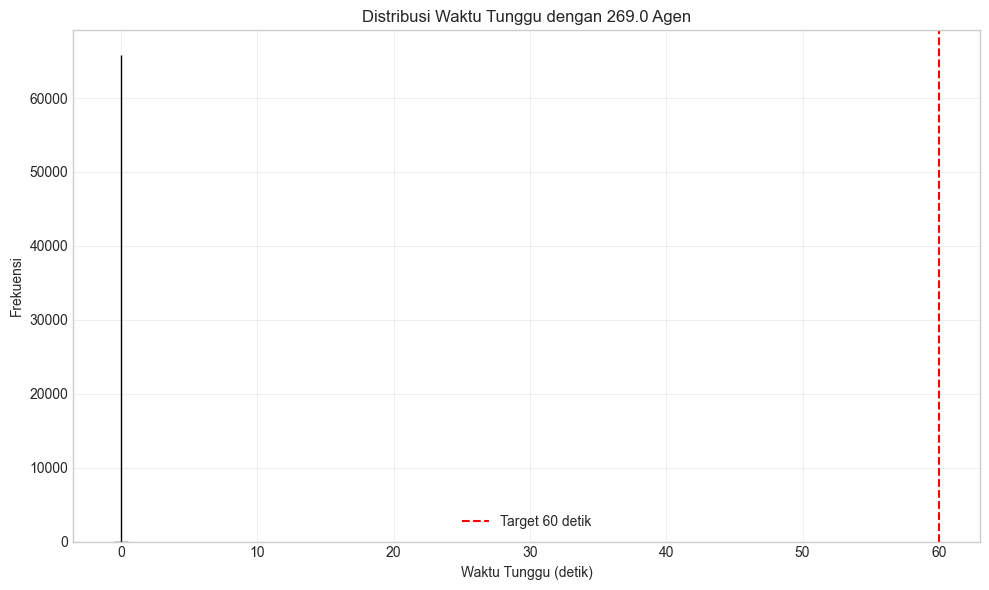

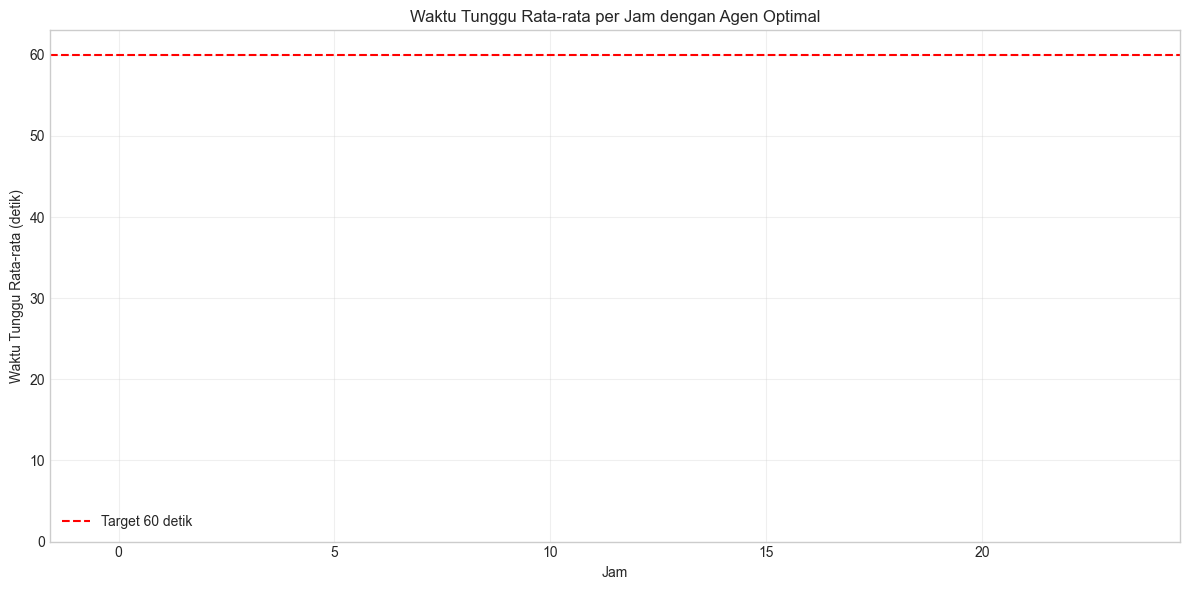

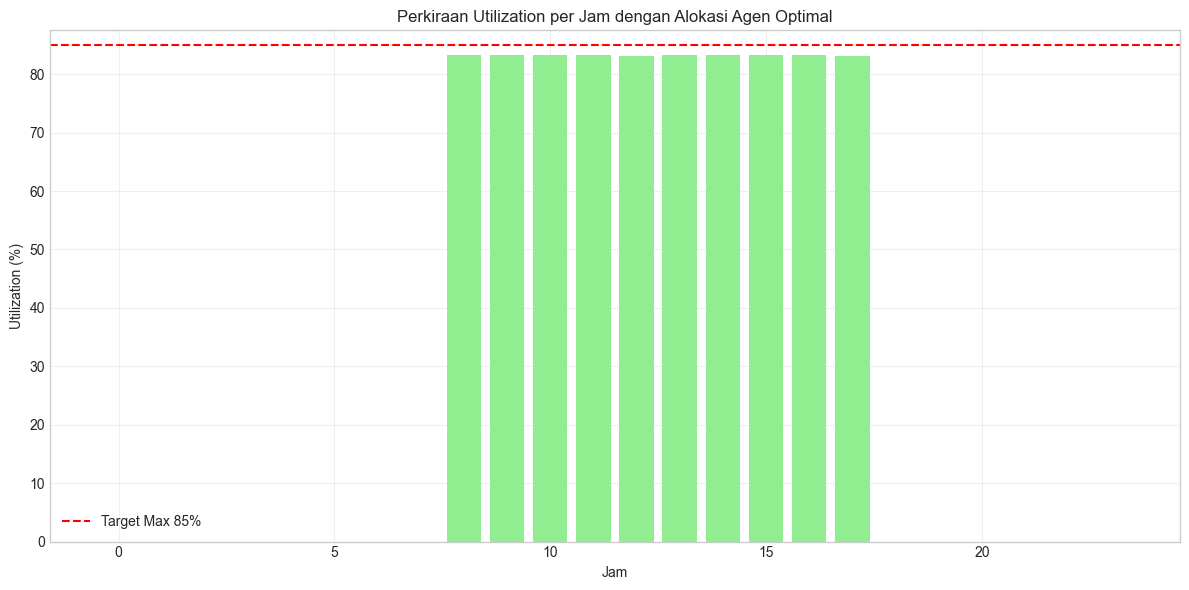

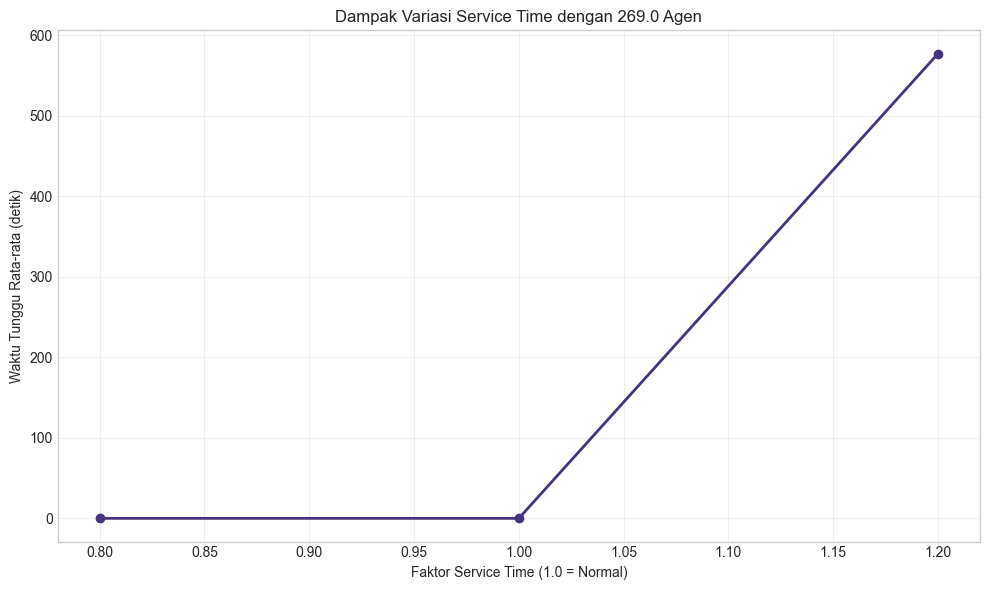

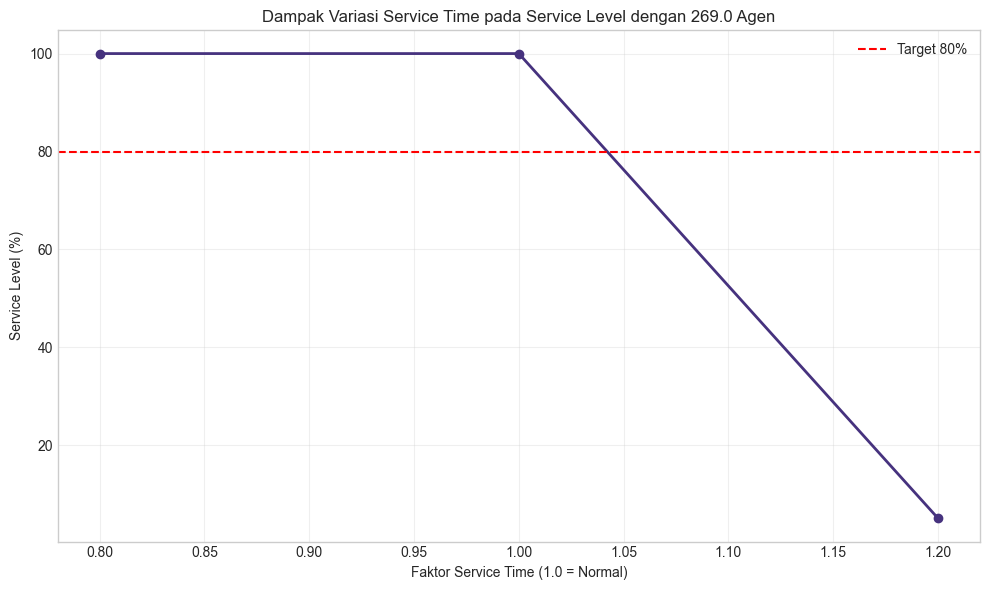

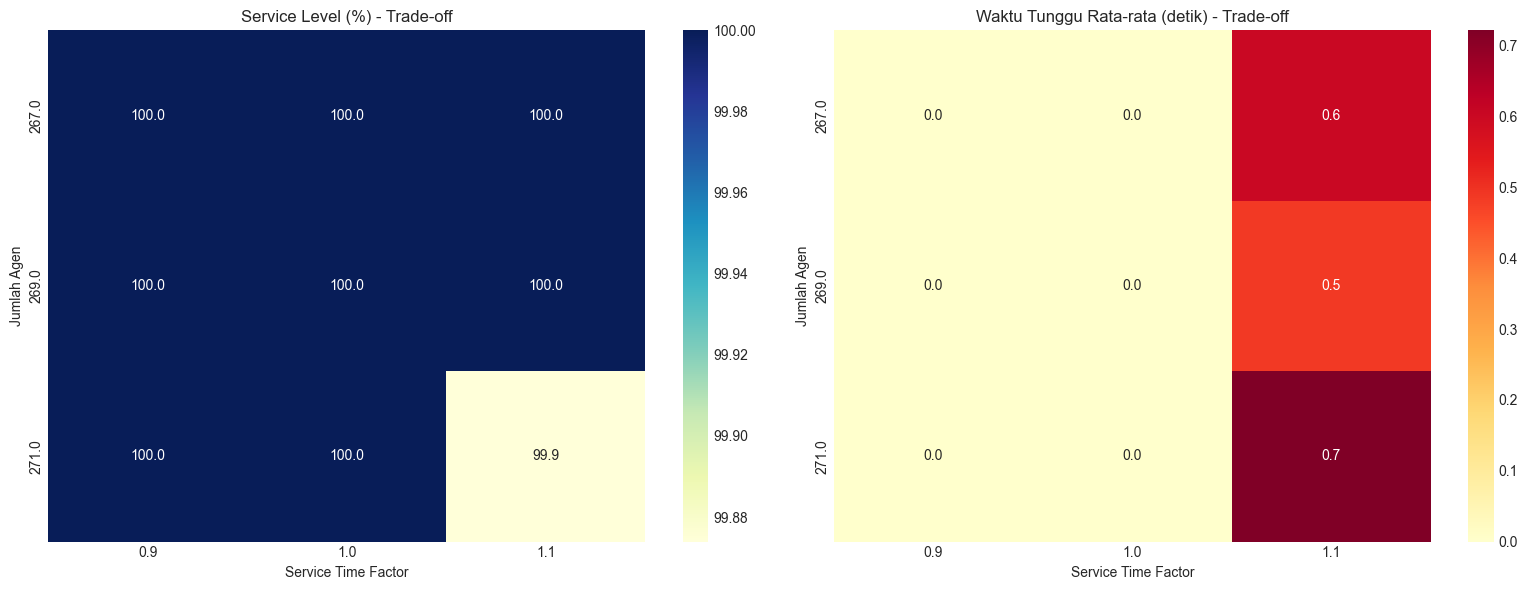


Ringkasan Hasil Simulasi dan Analisis:
1. Jumlah agen optimal: 269.0
2. Service level dengan agen optimal: 100.00%
3. Waktu tunggu rata-rata dengan agen optimal: 0.00 detik
4. Utilization agen dengan agen optimal: 84.01%

Rekomendasi:
1. Alokasikan agen sesuai dengan pola kedatangan panggilan per jam
2. Pertimbangkan untuk meningkatkan jumlah agen pada jam sibuk
3. Evaluasi upaya untuk mengurangi waktu layanan rata-rata
4. Pantau utilization agen untuk memastikan efisiensi dan pencegahan burnout

Analisis Selesai. Semua grafik dan visualisasi telah disimpan.


In [12]:
# ==========================================
# 5. Plot Additional Insights
# ==========================================
print("\nStep 5: Plot Additional Insights")

# 1. Simulasi dengan agen optimal untuk melihat distribusi waktu tunggu lebih detail
optimal_sim = CallCenterSimulation(
    arrival_dist=arrival_dist, 
    arrival_params=arrival_params,
    service_dist=service_dist, 
    service_params=service_params,
    num_agents=int(optimal_agent_count),
    simulation_duration=simulation_duration,
    warm_up_time=warm_up_time
)

optimal_sim.run_simulation()
completed_calls = optimal_sim.get_completed_calls()

# Ekstrak data waktu tunggu untuk visualisasi
wait_times = [call['wait_time'] for call in completed_calls]

# Distribusi waktu tunggu dengan agen optimal
plt.figure(figsize=(10, 6))
sns.histplot(wait_times, kde=True, bins=50)
plt.axvline(x=60, color='r', linestyle='--', label='Target 60 detik')
plt.title(f'Distribusi Waktu Tunggu dengan {optimal_agent_count} Agen')
plt.xlabel('Waktu Tunggu (detik)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimal_wait_time_distribution.png')
plt.show()

# 2. Simulasi panjang antrian sepanjang hari
# Tracking panjang antrian per jam
hourly_queue_lengths = defaultdict(list)
hourly_wait_times = defaultdict(list)

for call in completed_calls:
    # Dapatkan jam dari waktu kedatangan
    arrival_hour = int((call['arrival_time'] % (24 * 3600)) / 3600)
    hourly_wait_times[arrival_hour].append(call['wait_time'])

# Agregasi data panjang antrian per jam
hourly_avg_queue = {}
hourly_avg_wait = {}

for hour in range(24):
    # Panjang antrian rata-rata per jam
    if hour in hourly_queue_lengths:
        hourly_avg_queue[hour] = np.mean(hourly_queue_lengths[hour])
    else:
        hourly_avg_queue[hour] = 0
    
    # Waktu tunggu rata-rata per jam
    if hour in hourly_wait_times:
        hourly_avg_wait[hour] = np.mean(hourly_wait_times[hour])
    else:
        hourly_avg_wait[hour] = 0

# Visualisasi waktu tunggu rata-rata per jam
plt.figure(figsize=(12, 6))
hours = list(range(24))
avg_wait_values = [hourly_avg_wait.get(h, 0) for h in hours]
plt.bar(hours, avg_wait_values, color='skyblue')
plt.axhline(y=60, color='r', linestyle='--', label='Target 60 detik')
plt.title('Waktu Tunggu Rata-rata per Jam dengan Agen Optimal')
plt.xlabel('Jam')
plt.ylabel('Waktu Tunggu Rata-rata (detik)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_avg_wait_time.png')
plt.show()

# 3. Analisis efisiensi alokasi agen
# Hitung utilization per jam
hourly_utilization = {}

for hour in range(24):
    if hour in hourly_agents_df['hour'].values:
        agents = hourly_agents_df.loc[hourly_agents_df['hour'] == hour, 'agents'].values[0]
        calls = hourly_agents_df.loc[hourly_agents_df['hour'] == hour, 'calls'].values[0]
        
        # Perkiraan utilization per jam
        hourly_service_rate = service_rate * agents * 3600  # Kapasitas per jam
        utilization = min(calls / hourly_service_rate * 100, 100) if hourly_service_rate > 0 else 100
        hourly_utilization[hour] = utilization

# Visualisasi utilization per jam
plt.figure(figsize=(12, 6))
hours = list(range(24))
utilization_values = [hourly_utilization.get(h, 0) for h in hours]
plt.bar(hours, utilization_values, color='lightgreen')
plt.axhline(y=85, color='r', linestyle='--', label='Target Max 85%')
plt.title('Perkiraan Utilization per Jam dengan Alokasi Agen Optimal')
plt.xlabel('Jam')
plt.ylabel('Utilization (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_utilization.png')
plt.show()

# 4. Analisis sensitivitas terhadap perubahan waktu layanan
service_variations = [0.8, 1.0, 1.2]  # 80%, 100%, 120% dari service time saat ini
service_variation_results = []

for variation in service_variations:
    # Modifikasi parameter distribusi untuk service time yang baru
    modified_service_params = list(service_params)
    modified_service_params[-1] = service_params[-1] * variation  # Ubah scale untuk mengubah service time
    
    sim = CallCenterSimulation(
        arrival_dist=arrival_dist, 
        arrival_params=arrival_params,
        service_dist=service_dist, 
        service_params=tuple(modified_service_params),
        num_agents=int(optimal_agent_count),
        simulation_duration=simulation_duration,
        warm_up_time=warm_up_time
    )
    
    sim.run_simulation()
    metrics = sim.get_performance_metrics()
    metrics['service_variation'] = variation
    service_variation_results.append(metrics)

service_variation_df = pd.DataFrame(service_variation_results)

# Visualisasi dampak variasi service time
plt.figure(figsize=(10, 6))
plt.plot(service_variation_df['service_variation'], service_variation_df['avg_wait_time'], 'o-', linewidth=2)
plt.title(f'Dampak Variasi Service Time dengan {optimal_agent_count} Agen')
plt.xlabel('Faktor Service Time (1.0 = Normal)')
plt.ylabel('Waktu Tunggu Rata-rata (detik)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('service_time_impact.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(service_variation_df['service_variation'], service_variation_df['service_level'], 'o-', linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='Target 80%')
plt.title(f'Dampak Variasi Service Time pada Service Level dengan {optimal_agent_count} Agen')
plt.xlabel('Faktor Service Time (1.0 = Normal)')
plt.ylabel('Service Level (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('service_time_impact_service_level.png')
plt.show()

# 5. Analisis trade-off antara jumlah agen dan service time
# Simulasi dengan berbagai kombinasi jumlah agen dan service time
agent_options = [optimal_agent_count - 2, optimal_agent_count, optimal_agent_count + 2]
service_options = [0.9, 1.0, 1.1]  # 90%, 100%, 110% dari service time saat ini

tradeoff_results = []

for num_agents in agent_options:
    for service_var in service_options:
        # Modifikasi parameter distribusi untuk service time yang baru
        modified_service_params = list(service_params)
        modified_service_params[-1] = service_params[-1] * service_var
        
        sim = CallCenterSimulation(
            arrival_dist=arrival_dist, 
            arrival_params=arrival_params,
            service_dist=service_dist, 
            service_params=tuple(modified_service_params),
            num_agents=int(num_agents),
            simulation_duration=simulation_duration,
            warm_up_time=warm_up_time
        )
        
        sim.run_simulation()
        metrics = sim.get_performance_metrics()
        metrics['num_agents'] = num_agents
        metrics['service_variation'] = service_var
        tradeoff_results.append(metrics)

tradeoff_df = pd.DataFrame(tradeoff_results)

# Visualisasi trade-off dengan heatmap
pivot_sl = pd.pivot_table(
    tradeoff_df, 
    values='service_level', 
    index='num_agents', 
    columns='service_variation'
)

pivot_wait = pd.pivot_table(
    tradeoff_df, 
    values='avg_wait_time', 
    index='num_agents', 
    columns='service_variation'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap untuk service level
sns.heatmap(pivot_sl, annot=True, cmap='YlGnBu', fmt='.1f', ax=ax1)
ax1.set_title('Service Level (%) - Trade-off')
ax1.set_xlabel('Service Time Factor')
ax1.set_ylabel('Jumlah Agen')

# Heatmap untuk waktu tunggu
sns.heatmap(pivot_wait, annot=True, cmap='YlOrRd', fmt='.1f', ax=ax2)
ax2.set_title('Waktu Tunggu Rata-rata (detik) - Trade-off')
ax2.set_xlabel('Service Time Factor')
ax2.set_ylabel('Jumlah Agen')

plt.tight_layout()
plt.savefig('tradeoff_heatmap.png')
plt.show()

# Ringkasan hasil simulasi
print("\nRingkasan Hasil Simulasi dan Analisis:")
print(f"1. Jumlah agen optimal: {optimal_agent_count}")
print(f"2. Service level dengan agen optimal: {optimal_sim.get_performance_metrics()['service_level']:.2f}%")
print(f"3. Waktu tunggu rata-rata dengan agen optimal: {optimal_sim.get_performance_metrics()['avg_wait_time']:.2f} detik")
print(f"4. Utilization agen dengan agen optimal: {optimal_sim.get_performance_metrics()['utilization']:.2f}%")
print("\nRekomendasi:")
print("1. Alokasikan agen sesuai dengan pola kedatangan panggilan per jam")
print("2. Pertimbangkan untuk meningkatkan jumlah agen pada jam sibuk")
print("3. Evaluasi upaya untuk mengurangi waktu layanan rata-rata")
print("4. Pantau utilization agen untuk memastikan efisiensi dan pencegahan burnout")

print("\nAnalisis Selesai. Semua grafik dan visualisasi telah disimpan.")